# Versao 13 - Visao Geral Dos Dados

A `versao13` investiga uma alternativa mais enxuta para o `3W`: uma rede `BiGRU + Multi-Head Attention`, inspirada no artigo fornecido, mas adaptada ao protocolo de pre-processamento mais estavel que o projeto ja construiu.


## Hipotese central

A ideia desta versao e simples:

- manter a limpeza de entrada que se mostrou util na `versao11`;
- manter o protocolo robusto de reamostragem e padronizacao da `versao10` e `versao12`;
- trocar a arquitetura hierarquica e multitarefa por uma leitura sequencial direta com `BiGRU`, `self-attention`, conexao residual e `global average pooling`;
- comparar esse desenho com as baselines tabulares no mesmo protocolo experimental.


In [43]:
from pathlib import Path
import sys

import pandas as pd

ROOT = Path.cwd()
PROJECT_ROOT = ROOT.parent if ROOT.name == 'versao13' else ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from versao13.pipeline_v13 import (
    ALL_NULL_FEATURE_COLUMNS,
    SELECTED_CONTINUOUS_SENSOR_COLUMNS,
    SELECTED_FEATURE_COLUMNS,
    SELECTED_STATE_SENSOR_COLUMNS,
    SOURCE_TYPE_MAPPING,
    build_feature_selection_report,
    discover_series_manifest,
    load_attribute_catalog,
    load_event_catalog,
)

DATASET_ROOT = PROJECT_ROOT / '3W' / 'dataset'
manifest = discover_series_manifest(DATASET_ROOT)
attribute_catalog = load_attribute_catalog(DATASET_ROOT)
event_catalog = load_event_catalog(DATASET_ROOT)
feature_report = build_feature_selection_report()

print('Numero total de series:', len(manifest))
print('Numero de classes globais:', manifest['class_label'].nunique())
print('Numero de fontes:', manifest['source_type'].nunique())
print('Features removidas:', ALL_NULL_FEATURE_COLUMNS)
print('Features mantidas:', len(SELECTED_FEATURE_COLUMNS))
print('Features continuas:', len(SELECTED_CONTINUOUS_SENSOR_COLUMNS))
print('Features de estado:', len(SELECTED_STATE_SENSOR_COLUMNS))
print('Mapeamento de origem:', SOURCE_TYPE_MAPPING)



Numero total de series: 2228
Numero de classes globais: 10
Numero de fontes: 3
Features removidas: ['ABER-CKGL', 'ABER-CKP', 'P-JUS-BS', 'P-JUS-CKP', 'P-MON-CKGL', 'P-MON-SDV-P', 'PT-P', 'QBS', 'T-MON-CKP']
Features mantidas: 18
Features continuas: 9
Features de estado: 9
Mapeamento de origem: {'well': 0, 'simulated': 1, 'drawn': 2}


In [44]:
resumo = pd.DataFrame(
    [
        {
            'n_series': len(manifest),
            'n_classes_globais': manifest['class_label'].nunique(),
            'n_sources': manifest['source_type'].nunique(),
            'n_features_originais': len(feature_report),
            'n_features_mantidas': int(feature_report['selected_for_modeling'].sum()),
            'n_features_removidas': int((~feature_report['selected_for_modeling']).sum()),
        }
    ]
)
display(resumo)
display(feature_report)
display(attribute_catalog.head())
display(event_catalog.head())



,n_series,n_classes_globais,n_sources,n_features_originais,n_features_mantidas,n_features_removidas
0,2228,10,3,27,18,9


,column,null_pct,selected_for_modeling,selection_reason,column_type
0,ABER-CKGL,100.0,False,all_null_feature_removed,continuous
1,ABER-CKP,100.0,False,all_null_feature_removed,continuous
2,ESTADO-DHSV,NaN,True,kept_for_modeling,state
3,ESTADO-M1,NaN,True,kept_for_modeling,state
4,ESTADO-M2,NaN,True,kept_for_modeling,state
5,ESTADO-PXO,NaN,True,kept_for_modeling,state
6,ESTADO-SDV-GL,NaN,True,kept_for_modeling,state
7,ESTADO-SDV-P,NaN,True,kept_for_modeling,state
8,ESTADO-W1,NaN,True,kept_for_modeling,state
9,ESTADO-W2,NaN,True,kept_for_modeling,state


,atributo,papel_no_pipeline,descricao_oficial
0,timestamp,metadado,Instant at which observation was generated
1,ABER-CKGL,metadado,Opening of the GLCK (gas lift choke) [%]
2,ABER-CKP,metadado,Opening of the PCK (production choke) [%]
3,ESTADO-DHSV,estado_discreto,"State of the DHSV (downhole safety valve) [0, ..."
4,ESTADO-M1,estado_discreto,"State of the PMV (production master valve) [0,..."


,class_label,event_name,description,transient_event
0,0,NORMAL,Normal Operation,False
1,1,ABRUPT_INCREASE_OF_BSW,Abrupt Increase of BSW,True
2,2,SPURIOUS_CLOSURE_OF_DHSV,Spurious Closure of DHSV,True
3,3,SEVERE_SLUGGING,Severe Slugging,False
4,4,FLOW_INSTABILITY,Flow Instability,False


## Composition by event type and data source

The table below summarizes how each event class is distributed across `real`, `simulated`, and `hand-drawn` samples. The chart complements the table by showing the same breakdown as stacked bars.


,Type of Event,Real,Simulated,Hand-Drawn,Total
0,0 - Normal Operation,594,0,0,594
1,1 - Abrupt Increase of BSW,4,114,10,128
2,2 - Spurious Closure of DHSV,22,16,0,38
3,3 - Severe Slugging,32,74,0,106
4,4 - Flow Instability,343,0,0,343
5,5 - Rapid Productivity Loss,11,439,0,450
6,6 - Quick Restriction in PCK,6,215,0,221
7,7 - Scaling in PCK,36,0,10,46
8,8 - Hydrate in Production Line,14,81,0,95
9,9 - Hydrate in Service Line,57,150,0,207


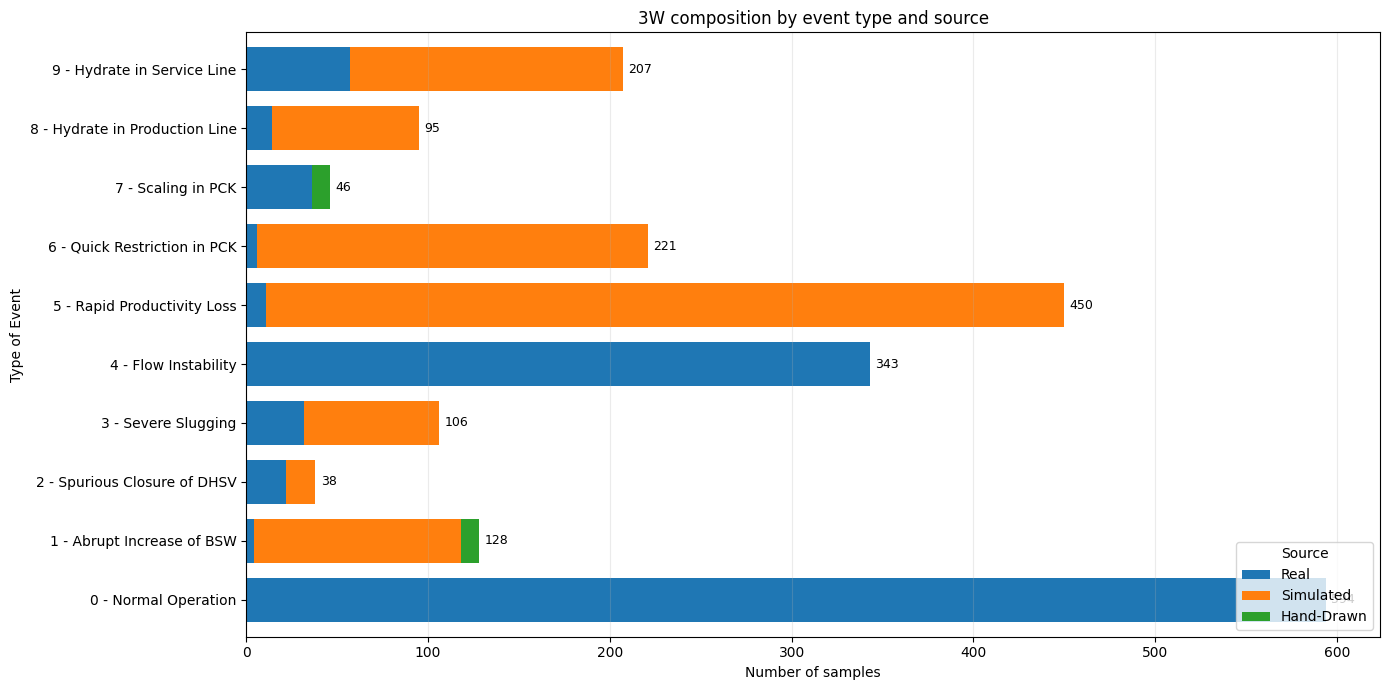

In [45]:
import matplotlib.pyplot as plt

source_counts = (
    manifest.assign(class_label_int=manifest['class_label_int'].astype(int))
    .groupby(['class_label_int', 'source_type'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['well', 'simulated', 'drawn'], fill_value=0)
    .reset_index()
)

event_lookup = (
    event_catalog.assign(class_label_int=event_catalog['class_label'].astype(int))
    [['class_label_int', 'description']]
    .rename(columns={'description': 'event_description'})
)

composition_table = source_counts.merge(event_lookup, on='class_label_int', how='left')
composition_table['Type of Event'] = composition_table.apply(
    lambda row: f"{row['class_label_int']} - {row['event_description']}",
    axis=1,
)
composition_table = composition_table.rename(
    columns={
        'well': 'Real',
        'simulated': 'Simulated',
        'drawn': 'Hand-Drawn',
    }
)
composition_table['Total'] = composition_table[['Real', 'Simulated', 'Hand-Drawn']].sum(axis=1)

composition_display = composition_table[['Type of Event', 'Real', 'Simulated', 'Hand-Drawn', 'Total']].copy()
total_row = pd.DataFrame(
    [{
        'Type of Event': 'Total',
        'Real': int(composition_display['Real'].sum()),
        'Simulated': int(composition_display['Simulated'].sum()),
        'Hand-Drawn': int(composition_display['Hand-Drawn'].sum()),
        'Total': int(composition_display['Total'].sum()),
    }]
)
composition_display = pd.concat([composition_display, total_row], ignore_index=True)
display(composition_display)

plot_df = composition_table[['Type of Event', 'Real', 'Simulated', 'Hand-Drawn']].copy()
plot_df = plot_df.set_index('Type of Event')

fig, ax = plt.subplots(figsize=(14, 7))
plot_df.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=['#1f77b4', '#ff7f0e', '#2ca02c'],
    width=0.75,
)
ax.set_title('3W composition by event type and source')
ax.set_xlabel('Number of samples')
ax.set_ylabel('Type of Event')
ax.legend(title='Source', loc='lower right')
ax.grid(axis='x', alpha=0.25)

for row_idx, (_, row) in enumerate(plot_df.iterrows()):
    total_value = int(row.sum())
    ax.text(total_value + 3, row_idx, str(total_value), va='center', fontsize=9)

plt.tight_layout()
plt.show()


## Number of series per well

The cell below summarizes how many real series are available for each well in the dataset. This view uses only samples with `source_type = well`.


,well_name,n_series
0,WELL-00002,326
1,WELL-00001,132
2,WELL-00005,119
3,WELL-00006,117
4,WELL-00010,89
5,WELL-00004,58
6,WELL-00008,57
7,WELL-00014,55
8,WELL-00003,29
9,WELL-00024,19


Number of real wells represented: 40
Total real series: 1119


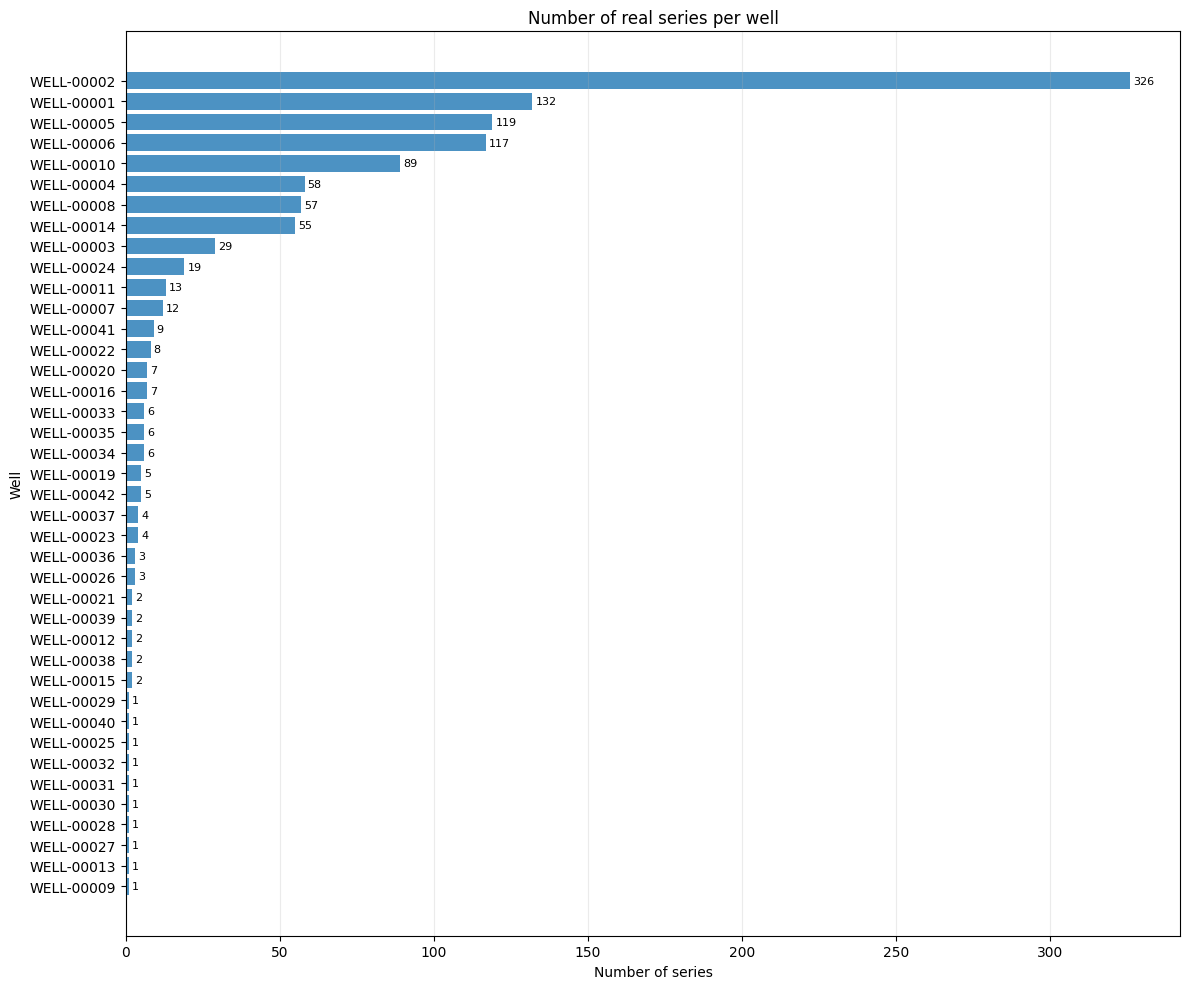

In [46]:
import matplotlib.pyplot as plt

well_manifest = manifest.loc[manifest['source_type'] == 'well'].copy()
series_per_well = (
    well_manifest['well_name']
    .value_counts()
    .rename_axis('well_name')
    .reset_index(name='n_series')
)

display(series_per_well)
print(f"Number of real wells represented: {series_per_well['well_name'].nunique()}")
print(f"Total real series: {series_per_well['n_series'].sum()}")

plot_df = series_per_well.sort_values('n_series', ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(plot_df['well_name'], plot_df['n_series'], color='#4c92c3')
ax.set_title('Number of real series per well')
ax.set_xlabel('Number of series')
ax.set_ylabel('Well')
ax.grid(axis='x', alpha=0.25)

for idx, row in enumerate(plot_df.itertuples(index=False)):
    ax.text(row.n_series + 1, idx, str(int(row.n_series)), va='center', fontsize=8)

plt.tight_layout()
plt.show()


## Desbalanceamento das classes

A distribuicao do `3W` e bastante desigual entre as classes. A celula abaixo resume o numero de series por evento, mostra a participacao percentual de cada classe e destaca a diferenca entre a classe majoritaria e a minoritaria.


,class_label,n_series,event_name,share_pct
0,0,594,NORMAL,26.66%
1,1,128,ABRUPT_INCREASE_OF_BSW,5.75%
2,2,38,SPURIOUS_CLOSURE_OF_DHSV,1.71%
3,3,106,SEVERE_SLUGGING,4.76%
4,4,343,FLOW_INSTABILITY,15.39%
5,5,450,RAPID_PRODUCTIVITY_LOSS,20.20%
6,6,221,QUICK_RESTRICTION_IN_PCK,9.92%
7,7,46,SCALING_IN_PCK,2.06%
8,8,95,HYDRATE_IN_PRODUCTION_LINE,4.26%
9,9,207,HYDRATE_IN_SERVICE_LINE,9.29%


Most frequent class: 0 (NORMAL) -> 594 series
Least frequent class: 2 (SPURIOUS_CLOSURE_OF_DHSV) -> 38 series
Imbalance ratio (majority/minority): 15.63x


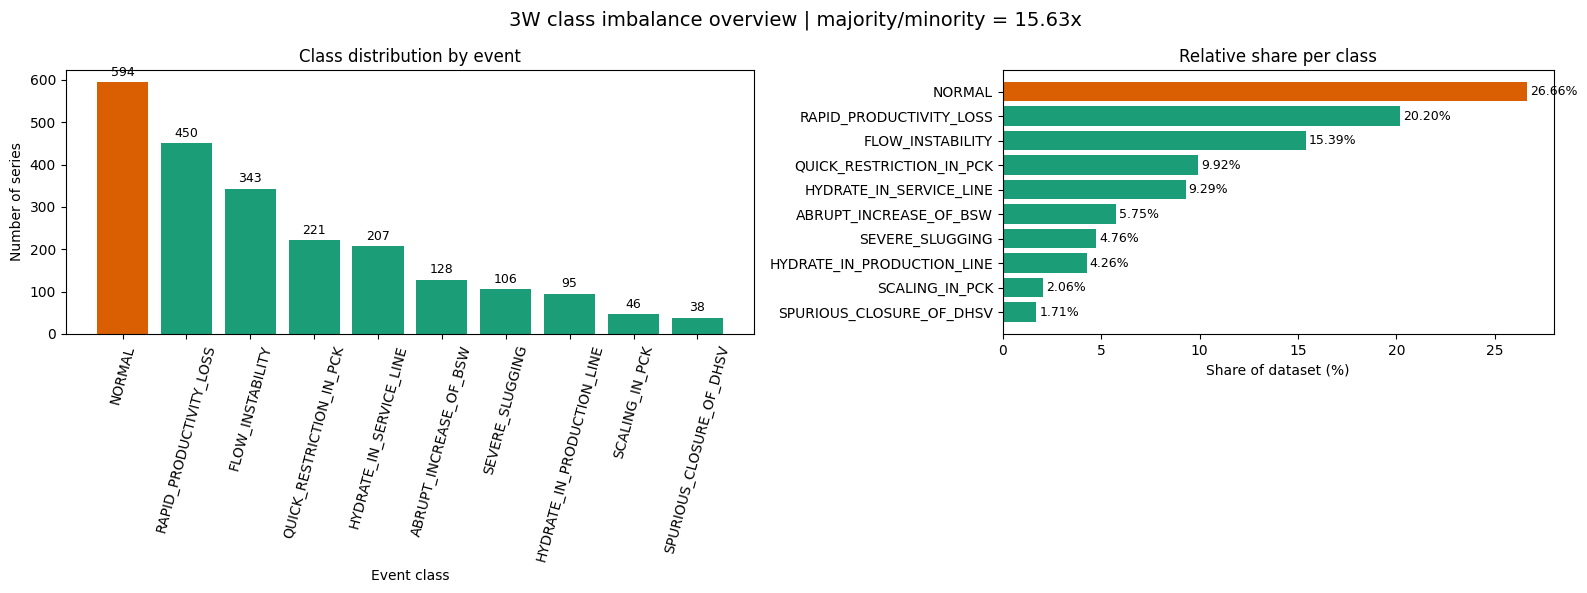

In [47]:
import matplotlib.pyplot as plt

class_balance = (
    manifest['class_label']
    .astype(int)
    .value_counts()
    .sort_index()
    .rename_axis('class_label')
    .reset_index(name='n_series')
)
class_balance = class_balance.merge(
    event_catalog[['class_label', 'event_name']],
    on='class_label',
    how='left',
)
class_balance['share_pct'] = 100 * class_balance['n_series'] / class_balance['n_series'].sum()

majority_row = class_balance.loc[class_balance['n_series'].idxmax()]
minority_row = class_balance.loc[class_balance['n_series'].idxmin()]
imbalance_ratio = majority_row['n_series'] / minority_row['n_series']

class_balance_display = class_balance.copy()
class_balance_display['share_pct'] = class_balance_display['share_pct'].map(lambda value: f'{value:.2f}%')
display(class_balance_display)

print(
    f"Most frequent class: {majority_row['class_label']} ({majority_row['event_name']}) -> {majority_row['n_series']} series"
)
print(
    f"Least frequent class: {minority_row['class_label']} ({minority_row['event_name']}) -> {minority_row['n_series']} series"
)
print(f'Imbalance ratio (majority/minority): {imbalance_ratio:.2f}x')

plot_df = class_balance.sort_values('n_series', ascending=False).reset_index(drop=True)
bar_colors = ['#d95f02' if label == 0 else '#1b9e77' for label in plot_df['class_label']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.25, 1.0]})

axes[0].bar(plot_df['event_name'], plot_df['n_series'], color=bar_colors)
axes[0].set_title('Class distribution by event')
axes[0].set_xlabel('Event class')
axes[0].set_ylabel('Number of series')
axes[0].tick_params(axis='x', rotation=75)
for idx, row in plot_df.iterrows():
    axes[0].text(idx, row['n_series'] + 8, str(int(row['n_series'])), ha='center', va='bottom', fontsize=9)

axes[1].barh(plot_df['event_name'], plot_df['share_pct'], color=bar_colors)
axes[1].invert_yaxis()
axes[1].set_title('Relative share per class')
axes[1].set_xlabel('Share of dataset (%)')
for idx, row in plot_df.iterrows():
    axes[1].text(row['share_pct'] + 0.15, idx, f"{row['share_pct']:.2f}%", va='center', fontsize=9)

fig.suptitle(
    f'3W class imbalance overview | majority/minority = {imbalance_ratio:.2f}x',
    fontsize=14,
)
plt.tight_layout()
plt.show()


## Missing data overview

O `3W` tambem se destaca pela alta quantidade de valores ausentes. A celula abaixo percorre o dataset inteiro, calcula o percentual de `NaN` por feature e resume quantas variaveis caem em cada faixa de missingness.


,column,n_total,n_missing,missing_pct,column_group
0,QBS,76587318,76587318,100.00%,continuous
1,P-MON-SDV-P,76587318,76587318,100.00%,continuous
2,P-JUS-BS,76587318,76587318,100.00%,continuous
3,PT-P,76587318,76587318,100.00%,continuous
4,P-MON-CKGL,76587318,76278592,99.60%,continuous
5,ABER-CKGL,76587318,68095805,88.91%,continuous
6,ABER-CKP,76587318,64260860,83.91%,continuous
7,ESTADO-DHSV,76587318,62721921,81.90%,state
8,ESTADO-SDV-GL,76587318,59482047,77.67%,state
9,ESTADO-M2,76587318,58899036,76.90%,state


,missing_range,n_features
0,0%,0
1,0-25%,5
2,25-50%,0
3,50-75%,7
4,75-100%,11
5,100%,4


Features with 100% missing values: 4
Features with at least 75% missing values: 15
Features with less than 25% missing values: 5


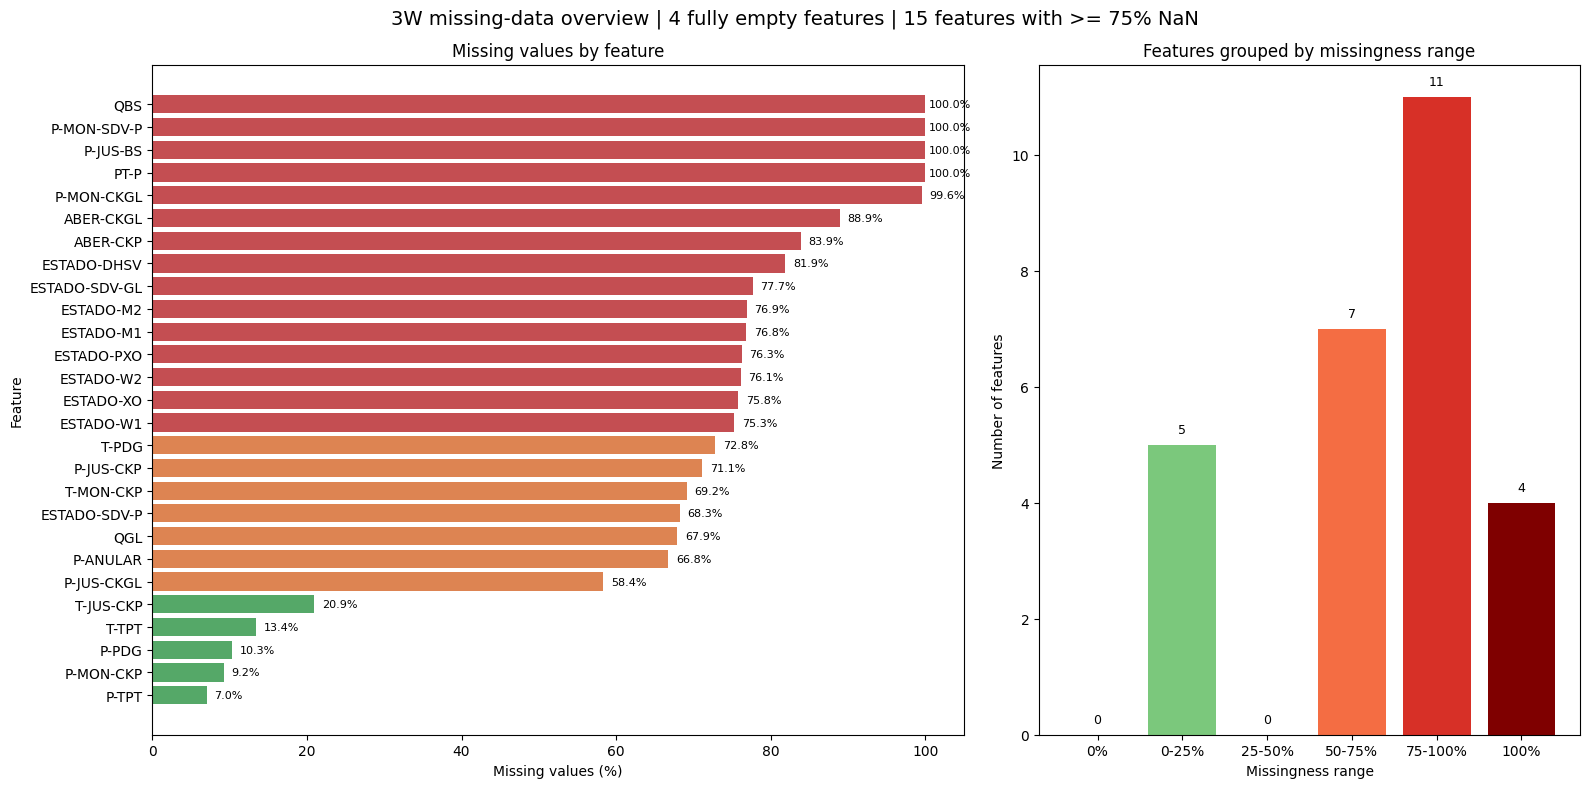

In [48]:
import matplotlib.pyplot as plt

exclude_columns = {'class', 'state'}
missing_counts = {}
total_counts = {}

for row in manifest.itertuples(index=False):
    frame = pd.read_parquet(row.file_path)
    feature_columns = [column for column in frame.columns if column not in exclude_columns]
    for column in feature_columns:
        series = frame[column]
        missing_counts[column] = missing_counts.get(column, 0) + int(series.isna().sum())
        total_counts[column] = total_counts.get(column, 0) + len(series)

missingness_df = pd.DataFrame({'column': sorted(total_counts)})
missingness_df['n_total'] = missingness_df['column'].map(total_counts)
missingness_df['n_missing'] = missingness_df['column'].map(missing_counts)
missingness_df['missing_pct'] = 100 * missingness_df['n_missing'] / missingness_df['n_total']
missingness_df['column_group'] = missingness_df['column'].map(
    lambda column: 'state' if column.startswith('ESTADO-') else 'continuous'
)
missingness_df = missingness_df.sort_values('missing_pct', ascending=False).reset_index(drop=True)

missingness_display = missingness_df.copy()
missingness_display['missing_pct'] = missingness_display['missing_pct'].map(lambda value: f'{value:.2f}%')
display(missingness_display)

missing_bins = pd.cut(
    missingness_df['missing_pct'],
    bins=[-0.1, 0, 25, 50, 75, 99.999, 100],
    labels=['0%', '0-25%', '25-50%', '50-75%', '75-100%', '100%'],
)
missing_bin_counts = (
    missing_bins.value_counts(sort=False)
    .rename_axis('missing_range')
    .reset_index(name='n_features')
)
display(missing_bin_counts)

fully_missing = int((missingness_df['missing_pct'] == 100).sum())
high_missing = int((missingness_df['missing_pct'] >= 75).sum())
low_missing = int((missingness_df['missing_pct'] < 25).sum())
print(f'Features with 100% missing values: {fully_missing}')
print(f'Features with at least 75% missing values: {high_missing}')
print(f'Features with less than 25% missing values: {low_missing}')

bar_colors = ['#c44e52' if value >= 75 else '#dd8452' if value >= 50 else '#55a868' for value in missingness_df['missing_pct']]

fig, axes = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [1.5, 1.0]})

axes[0].barh(missingness_df['column'], missingness_df['missing_pct'], color=bar_colors)
axes[0].invert_yaxis()
axes[0].set_title('Missing values by feature')
axes[0].set_xlabel('Missing values (%)')
axes[0].set_ylabel('Feature')
for idx, row in missingness_df.iterrows():
    axes[0].text(min(row['missing_pct'] + 1.0, 100.5), idx, f"{row['missing_pct']:.1f}%", va='center', fontsize=8)

range_colors = ['#4daf4a', '#7bc87c', '#fdae61', '#f46d43', '#d73027', '#7f0000']
axes[1].bar(missing_bin_counts['missing_range'].astype(str), missing_bin_counts['n_features'], color=range_colors)
axes[1].set_title('Features grouped by missingness range')
axes[1].set_xlabel('Missingness range')
axes[1].set_ylabel('Number of features')
for idx, row in missing_bin_counts.iterrows():
    axes[1].text(idx, row['n_features'] + 0.15, str(int(row['n_features'])), ha='center', va='bottom', fontsize=9)

fig.suptitle(
    f'3W missing-data overview | {fully_missing} fully empty features | {high_missing} features with >= 75% NaN',
    fontsize=14,
)
plt.tight_layout()
plt.show()


## Correlation heatmap

The following cell builds a Pearson correlation map for the `9` selected continuous features. To keep the notebook responsive, it concatenates a controlled sample of series from the dataset and computes the correlations on the combined frame.


,P-ANULAR,P-JUS-CKGL,P-MON-CKP,P-TPT,T-JUS-CKP,T-TPT
P-ANULAR,1.000,0.942,0.994,0.996,-0.992,-0.923
P-JUS-CKGL,0.942,1.000,0.961,0.958,-0.968,-0.817
P-MON-CKP,0.994,0.961,1.000,0.998,-0.996,-0.902
P-TPT,0.996,0.958,0.998,1.000,-0.996,-0.907
T-JUS-CKP,-0.992,-0.968,-0.996,-0.996,1.000,0.908
T-TPT,-0.923,-0.817,-0.902,-0.907,0.908,1.000


Series used for correlation: 40
Rows in concatenated sample: 866294
Features used in the heatmap: ['P-ANULAR', 'P-JUS-CKGL', 'P-MON-CKP', 'P-TPT', 'T-JUS-CKP', 'T-TPT']
Features dropped because they were all NaN: ['P-PDG', 'QGL', 'T-PDG']


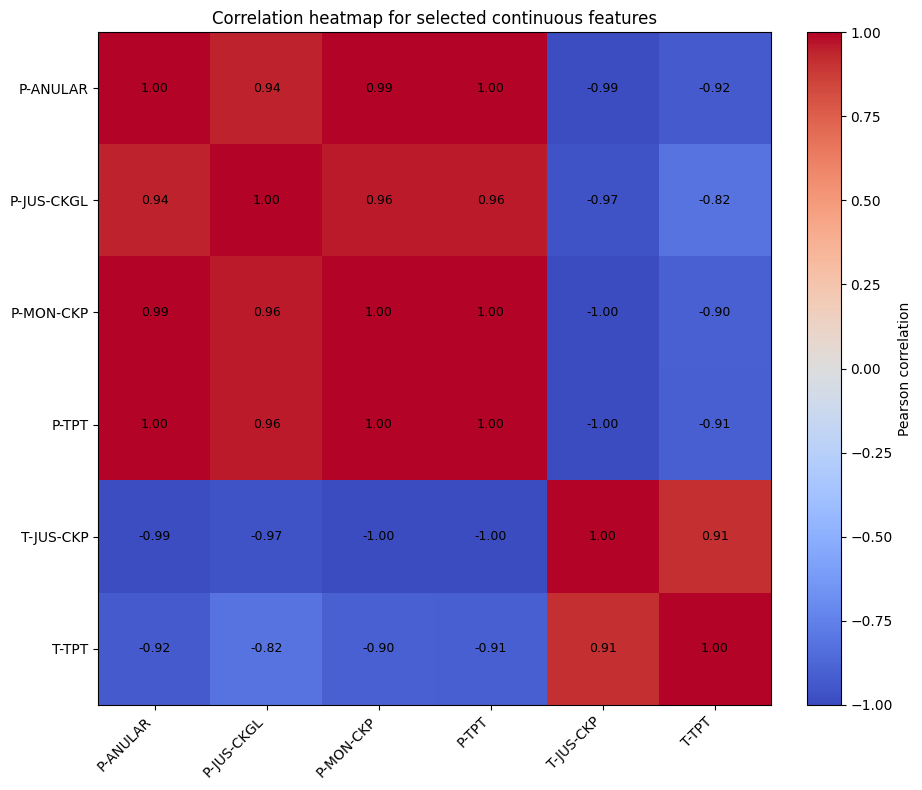

In [49]:
import matplotlib.pyplot as plt
import numpy as np

CORRELATION_FEATURES = SELECTED_CONTINUOUS_SENSOR_COLUMNS.copy()
MAX_SERIES_FOR_CORRELATION = 40

correlation_frames = []
for row in manifest.head(MAX_SERIES_FOR_CORRELATION).itertuples(index=False):
    frame = pd.read_parquet(row.file_path)
    available_columns = [column for column in CORRELATION_FEATURES if column in frame.columns]
    if available_columns:
        correlation_frames.append(frame[available_columns])

if not correlation_frames:
    raise ValueError('No series were available to compute the correlation matrix.')

correlation_sample = pd.concat(correlation_frames, ignore_index=True)
correlation_sample = correlation_sample.apply(pd.to_numeric, errors='coerce')
correlation_matrix = correlation_sample[CORRELATION_FEATURES].corr(method='pearson')
valid_correlation_mask = ~correlation_matrix.isna().all(axis=1)
used_correlation_features = valid_correlation_mask.loc[valid_correlation_mask].index.tolist()
dropped_correlation_features = valid_correlation_mask.loc[~valid_correlation_mask].index.tolist()
correlation_matrix = correlation_matrix.loc[used_correlation_features, used_correlation_features]

if correlation_matrix.empty:
    raise ValueError('All correlation features were empty or undefined for this sample.')

display(correlation_matrix.round(3))
print(f'Series used for correlation: {min(MAX_SERIES_FOR_CORRELATION, len(manifest))}')
print(f'Rows in concatenated sample: {len(correlation_sample)}')
print(f'Features used in the heatmap: {used_correlation_features}')
print(f'Features dropped because they were all NaN: {dropped_correlation_features}')

fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.imshow(correlation_matrix.to_numpy(), cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(used_correlation_features)))
ax.set_yticks(np.arange(len(used_correlation_features)))
ax.set_xticklabels(used_correlation_features, rotation=45, ha='right')
ax.set_yticklabels(used_correlation_features)
ax.set_title('Correlation heatmap for selected continuous features')

for row_idx in range(len(used_correlation_features)):
    for col_idx in range(len(used_correlation_features)):
        cell_value = correlation_matrix.iloc[row_idx, col_idx]
        label = 'NaN' if pd.isna(cell_value) else f'{cell_value:.2f}'
        ax.text(
            col_idx,
            row_idx,
            label,
            ha='center',
            va='center',
            color='black',
            fontsize=9,
        )

colorbar = fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label('Pearson correlation')
plt.tight_layout()
plt.show()


## Leitura academica

A `versao13` nao tenta ser a rede mais complexa do projeto. Ela tenta ser a rede **mais alinhada com o bloco BiGRU + atencao** sem perder o rigor do pre-processamento ja consolidado nas versoes recentes.


## Different sequence lengths across wells

The cell below illustrates that the same feature can appear in samples with different lengths when the data comes from different wells. Here, we compare `T-TPT` for `Class 2` using one real sample from `WELL-00002` and one from `WELL-00003`.


Loaded parquet for WELL-00002: /home/tiagoriosrocha/Desktop/lstm-w3/3W/dataset/2/WELL-00002_20131104004101.parquet
Samples used for WELL-00002: 12721
Loaded parquet for WELL-00003: /home/tiagoriosrocha/Desktop/lstm-w3/3W/dataset/2/WELL-00003_20141122190000.parquet
Samples used for WELL-00003: 19290


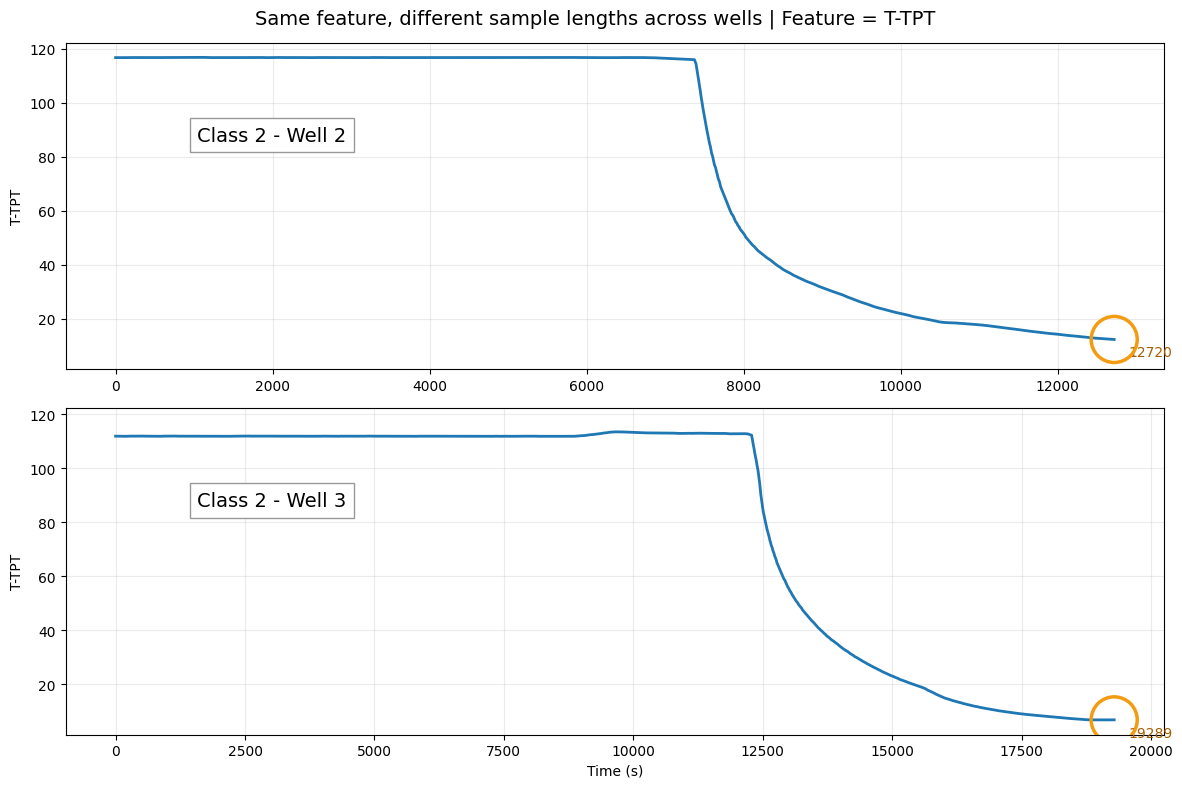

In [50]:
import matplotlib.pyplot as plt

TARGET_FEATURE = 'T-TPT'
TARGET_CLASS = 2
TARGET_WELLS = ['WELL-00002', 'WELL-00003']

selected_examples = []
for well_name in TARGET_WELLS:
    candidate_rows = manifest.loc[
        (manifest['class_label_int'] == TARGET_CLASS)
        & (manifest['source_type'] == 'well')
        & (manifest['well_name'] == well_name)
    ]
    if candidate_rows.empty:
        raise ValueError(f'No real samples found for {well_name} in class {TARGET_CLASS}.')

    best_example = None
    best_length = -1
    for _, candidate_row in candidate_rows.iterrows():
        candidate_path = Path(candidate_row['file_path'])
        candidate_df = pd.read_parquet(candidate_path)
        feature_series = candidate_df[TARGET_FEATURE].dropna()
        if len(feature_series) > best_length:
            best_length = len(feature_series)
            best_example = {
                'well_name': well_name,
                'file_path': candidate_path,
                'series': feature_series,
            }

    if best_example is None or best_length <= 0:
        raise ValueError(f'No non-empty {TARGET_FEATURE} series found for {well_name}.')
    selected_examples.append(best_example)

y_min = min(example['series'].min() for example in selected_examples)
y_max = max(example['series'].max() for example in selected_examples)
y_margin = 0.05 * (y_max - y_min) if y_max > y_min else 1.0

fig, axes = plt.subplots(len(selected_examples), 1, figsize=(12, 8), sharex=False)
if len(selected_examples) == 1:
    axes = [axes]

for ax, example in zip(axes, selected_examples):
    series_df = example['series'].to_frame(name=TARGET_FEATURE).copy()
    series_df.index = pd.to_datetime(series_df.index)
    series_df = series_df.sort_index()
    series_df['seconds'] = (series_df.index - series_df.index.min()).total_seconds()

    ax.plot(series_df['seconds'], series_df[TARGET_FEATURE], color='#1f77b4', linewidth=2.0)
    ax.set_ylabel(TARGET_FEATURE)
    ax.set_ylim(y_min - y_margin, y_max + y_margin)
    ax.grid(True, alpha=0.25)

    well_number = int(example['well_name'].split('-')[-1])
    end_seconds = float(series_df['seconds'].iloc[-1])
    end_value = float(series_df[TARGET_FEATURE].iloc[-1])

    ax.text(
        0.12,
        0.70,
        f'Class {TARGET_CLASS} - Well {well_number}',
        transform=ax.transAxes,
        fontsize=14,
        bbox=dict(facecolor='white', edgecolor='0.6', boxstyle='square,pad=0.4'),
    )
    ax.scatter(
        [end_seconds],
        [end_value],
        s=1100,
        facecolors='none',
        edgecolors='#f39c12',
        linewidths=2.5,
        zorder=5,
    )
    ax.annotate(
        f'{int(round(end_seconds))}',
        xy=(end_seconds, end_value),
        xytext=(10, -12),
        textcoords='offset points',
        fontsize=10,
        color='#a65e00',
    )
    print(f"Loaded parquet for {example['well_name']}: {example['file_path']}")
    print(f"Samples used for {example['well_name']}: {len(series_df)}")

axes[-1].set_xlabel('Time (s)')
fig.suptitle(
    f'Same feature, different sample lengths across wells | Feature = {TARGET_FEATURE}',
    fontsize=14,
)
plt.tight_layout()
plt.show()


## Different operating magnitudes across wells

The next cell shows that raw sensor values can live at very different operating scales across wells, even when both samples belong to the same `Class 0` (normal operation). The comparison below uses two real wells and keeps the signals in their original units.


Loaded parquet for WELL-00006: /home/tiagoriosrocha/Desktop/lstm-w3/3W/dataset/0/WELL-00006_20170818080000.parquet
  Mean P-PDG: 4.4858e+07
  Mean P-TPT: 2.12033e+07
  Mean QGL: 0.000534213
  Mean T-PDG: 36.2347
  Mean T-TPT: 116.488
Loaded parquet for WELL-00007: /home/tiagoriosrocha/Desktop/lstm-w3/3W/dataset/0/WELL-00007_20170801170000.parquet
  Mean P-PDG: 2.24501e+07
  Mean P-TPT: 1.30299e+07
  Mean QGL: 1.57954
  Mean T-PDG: 61.1834
  Mean T-TPT: 55.7898


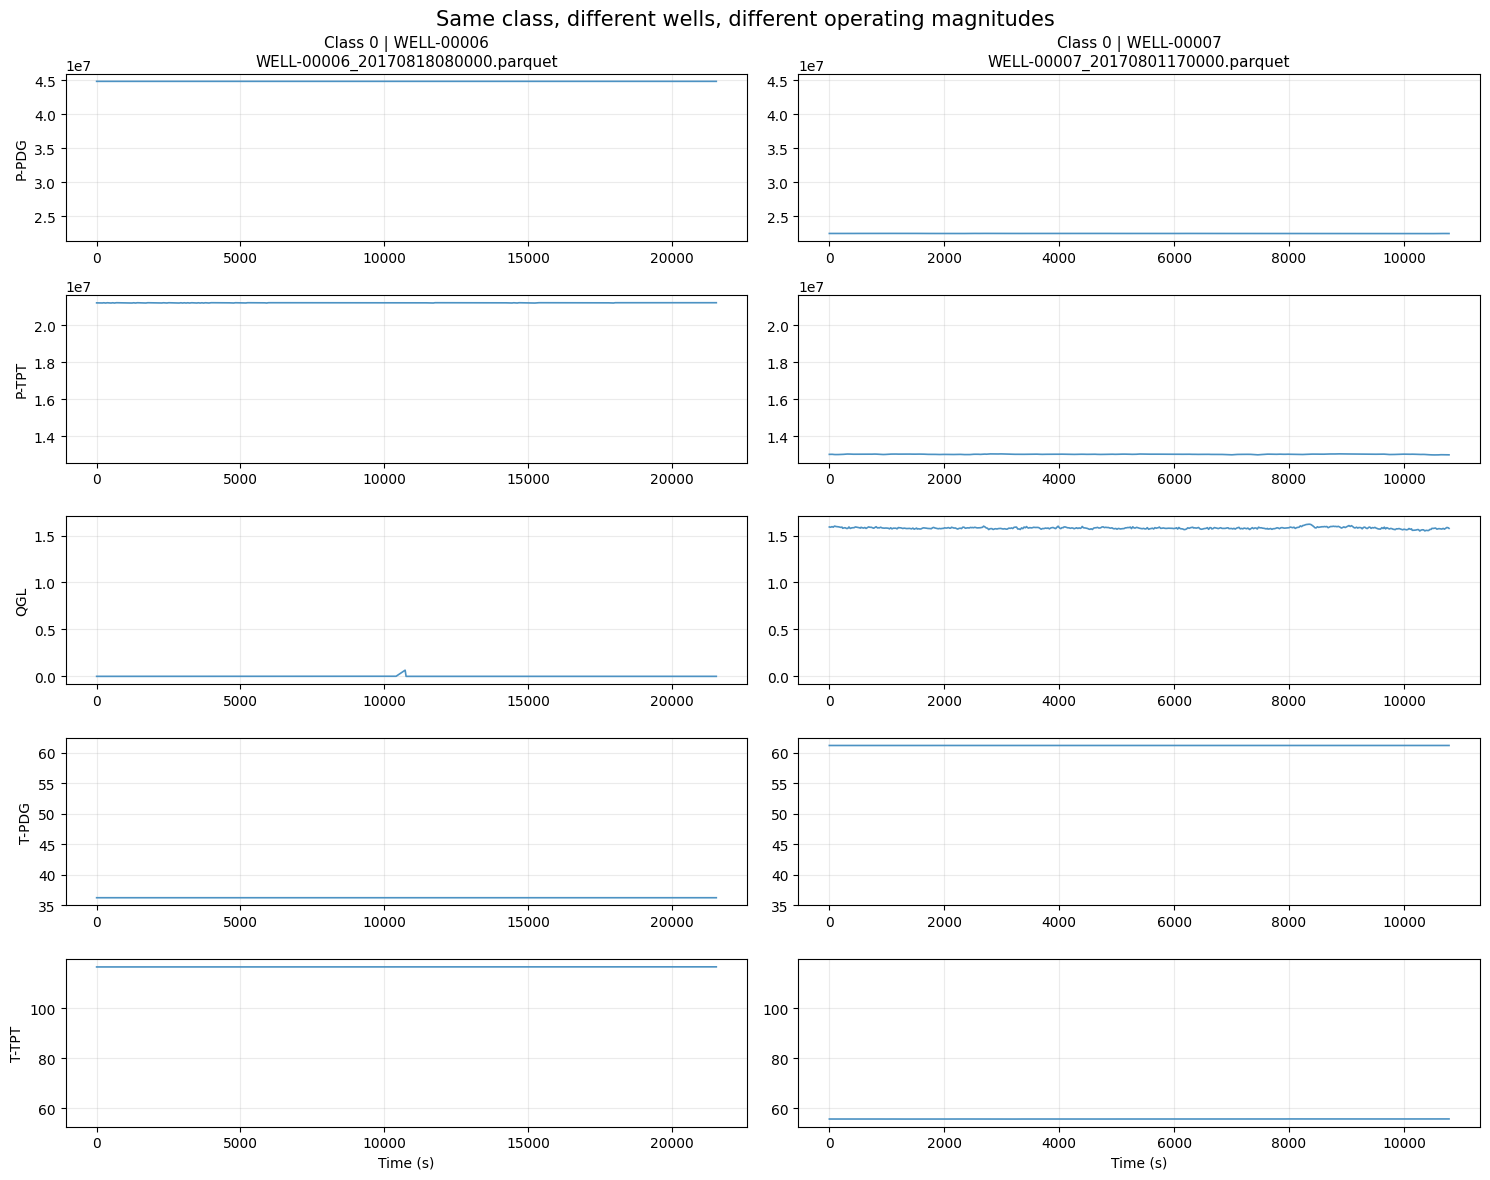

In [51]:
import matplotlib.pyplot as plt
import numpy as np

TARGET_CLASS = 0
TARGET_WELLS = ['WELL-00006', 'WELL-00007']
TARGET_FEATURES = ['P-PDG', 'P-TPT', 'QGL', 'T-PDG', 'T-TPT']

selected_examples = []
for well_name in TARGET_WELLS:
    candidate_rows = manifest.loc[
        (manifest['class_label_int'] == TARGET_CLASS)
        & (manifest['source_type'] == 'well')
        & (manifest['well_name'] == well_name)
    ]
    if candidate_rows.empty:
        raise ValueError(f'No real samples found for {well_name} in class {TARGET_CLASS}.')

    best_example = None
    best_score = None
    for _, candidate_row in candidate_rows.iterrows():
        candidate_path = Path(candidate_row['file_path'])
        candidate_df = pd.read_parquet(candidate_path).copy()
        non_null_count = 0
        non_zero_feature_count = 0
        feature_means = {}
        for feature_name in TARGET_FEATURES:
            feature_series = candidate_df[feature_name].dropna()
            non_null_count += len(feature_series)
            if len(feature_series) > 0:
                feature_mean = float(feature_series.mean())
                feature_means[feature_name] = feature_mean
                if not np.isclose(feature_mean, 0.0):
                    non_zero_feature_count += 1
            else:
                feature_means[feature_name] = np.nan

        score = (non_zero_feature_count, non_null_count, len(candidate_df))
        if best_score is None or score > best_score:
            best_score = score
            best_example = {
                'well_name': well_name,
                'file_path': candidate_path,
                'dataframe': candidate_df,
                'feature_means': feature_means,
            }

    if best_example is None:
        raise ValueError(f'Could not select a representative sample for {well_name}.')
    selected_examples.append(best_example)

feature_limits = {}
for feature_name in TARGET_FEATURES:
    feature_values = []
    for example in selected_examples:
        current_values = example['dataframe'][feature_name].dropna().to_numpy()
        if current_values.size > 0:
            feature_values.append(current_values)
    combined_values = np.concatenate(feature_values)
    value_min = float(combined_values.min())
    value_max = float(combined_values.max())
    margin = 0.05 * (value_max - value_min) if value_max > value_min else 1.0
    feature_limits[feature_name] = (value_min - margin, value_max + margin)

fig, axes = plt.subplots(len(TARGET_FEATURES), len(selected_examples), figsize=(15, 12), squeeze=False)

for column_idx, example in enumerate(selected_examples):
    example_df = example['dataframe'].copy()
    example_df.index = pd.to_datetime(example_df.index)
    example_df = example_df.sort_index()
    example_df['seconds'] = (example_df.index - example_df.index.min()).total_seconds()

    print(f"Loaded parquet for {example['well_name']}: {example['file_path']}")
    for feature_name in TARGET_FEATURES:
        print(f"  Mean {feature_name}: {example['feature_means'][feature_name]:.6g}")

    for row_idx, feature_name in enumerate(TARGET_FEATURES):
        ax = axes[row_idx, column_idx]
        feature_frame = example_df[['seconds', feature_name]].dropna()
        ax.plot(feature_frame['seconds'], feature_frame[feature_name], color='#4c92c3', linewidth=1.2)
        ax.set_ylim(*feature_limits[feature_name])
        ax.grid(True, alpha=0.25)
        if column_idx == 0:
            ax.set_ylabel(feature_name)
        if row_idx == 0:
            ax.set_title(f"Class {TARGET_CLASS} | {example['well_name']}\n{example['file_path'].name}", fontsize=11)
        if row_idx == len(TARGET_FEATURES) - 1:
            ax.set_xlabel('Time (s)')

fig.suptitle(
    'Same class, different wells, different operating magnitudes',
    fontsize=15,
)
plt.tight_layout()
plt.show()


## Same class, different variable behaviors

Even under `Class 0` (normal operation), the same set of variables can behave very differently across series. This may happen because the samples come from different wells, different acquisition periods, and different production architectures. In the plots below, the highlighted red line (`P-PDG`) changes substantially from one normal series to another.


Loaded parquet for WELL-00006: /home/tiagoriosrocha/Desktop/lstm-w3/3W/dataset/0/WELL-00006_20170506060114.parquet
Date range: 2017-05-06 06:01:14 -> 2017-05-06 12:00:00 | Samples: 21527
Loaded parquet for WELL-00007: /home/tiagoriosrocha/Desktop/lstm-w3/3W/dataset/0/WELL-00007_20170801170000.parquet
Date range: 2017-08-01 17:00:00 -> 2017-08-01 19:59:44 | Samples: 10785


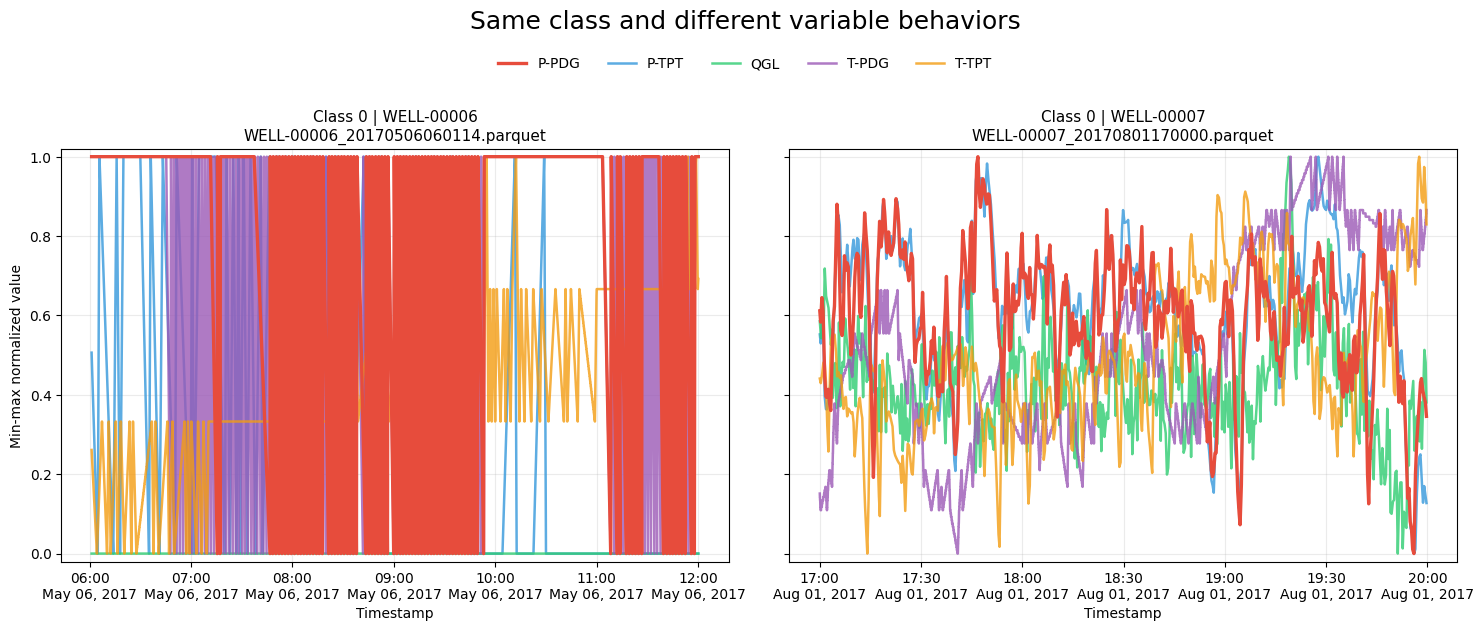

In [52]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

HIGHLIGHT_FEATURE = 'P-PDG'
COMPARISON_FEATURES = ['P-PDG', 'P-TPT', 'QGL', 'T-PDG', 'T-TPT']
COMPARISON_SERIES = [
    {
        'class_label': 0,
        'well_name': 'WELL-00006',
        'file_path': PROJECT_ROOT / '3W' / 'dataset' / '0' / 'WELL-00006_20170506060114.parquet',
    },
    {
        'class_label': 0,
        'well_name': 'WELL-00007',
        'file_path': PROJECT_ROOT / '3W' / 'dataset' / '0' / 'WELL-00007_20170801170000.parquet',
    },
]

feature_colors = {
    'P-PDG': '#e74c3c',
    'P-TPT': '#3498db',
    'QGL': '#2ecc71',
    'T-PDG': '#9b59b6',
    'T-TPT': '#f39c12',
}

fig, axes = plt.subplots(1, len(COMPARISON_SERIES), figsize=(15, 5.8), sharey=True)
if len(COMPARISON_SERIES) == 1:
    axes = [axes]

for ax, series_config in zip(axes, COMPARISON_SERIES):
    series_path = Path(series_config['file_path'])
    if not series_path.exists():
        raise FileNotFoundError(f'Missing parquet file: {series_path}')

    series_df = pd.read_parquet(series_path).copy()
    series_df.index = pd.to_datetime(series_df.index)
    series_df = series_df.sort_index()

    print(f"Loaded parquet for {series_config['well_name']}: {series_path}")
    print(f"Date range: {series_df.index.min()} -> {series_df.index.max()} | Samples: {len(series_df)}")

    for feature_name in COMPARISON_FEATURES:
        feature_series = pd.to_numeric(series_df[feature_name], errors='coerce')
        feature_min = feature_series.min(skipna=True)
        feature_max = feature_series.max(skipna=True)

        if pd.isna(feature_min) or pd.isna(feature_max):
            continue
        if np.isclose(feature_max, feature_min):
            normalized_series = pd.Series(np.zeros(len(feature_series)), index=feature_series.index)
        else:
            normalized_series = (feature_series - feature_min) / (feature_max - feature_min)

        linewidth = 2.4 if feature_name == HIGHLIGHT_FEATURE else 1.8
        alpha = 1.0 if feature_name == HIGHLIGHT_FEATURE else 0.8
        zorder = 5 if feature_name == HIGHLIGHT_FEATURE else 3
        ax.plot(
            normalized_series.index,
            normalized_series,
            color=feature_colors[feature_name],
            linewidth=linewidth,
            alpha=alpha,
            label=feature_name,
            zorder=zorder,
        )

    ax.set_title(
        f"Class {series_config['class_label']} | {series_config['well_name']}\n{series_path.name}",
        fontsize=11,
    )
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M\n%b %d, %Y'))
    if ax is axes[0]:
        ax.set_ylabel('Min-max normalized value')
    ax.set_xlabel('Timestamp')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(COMPARISON_FEATURES), frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Same class and different variable behaviors', fontsize=18, y=1.08)
plt.tight_layout()
plt.show()


## Detailed views for the green and yellow lines

The next cell isolates the green line (`QGL`) and the yellow line (`T-TPT`) so their behaviors can be inspected in more detail across the same two normal series.


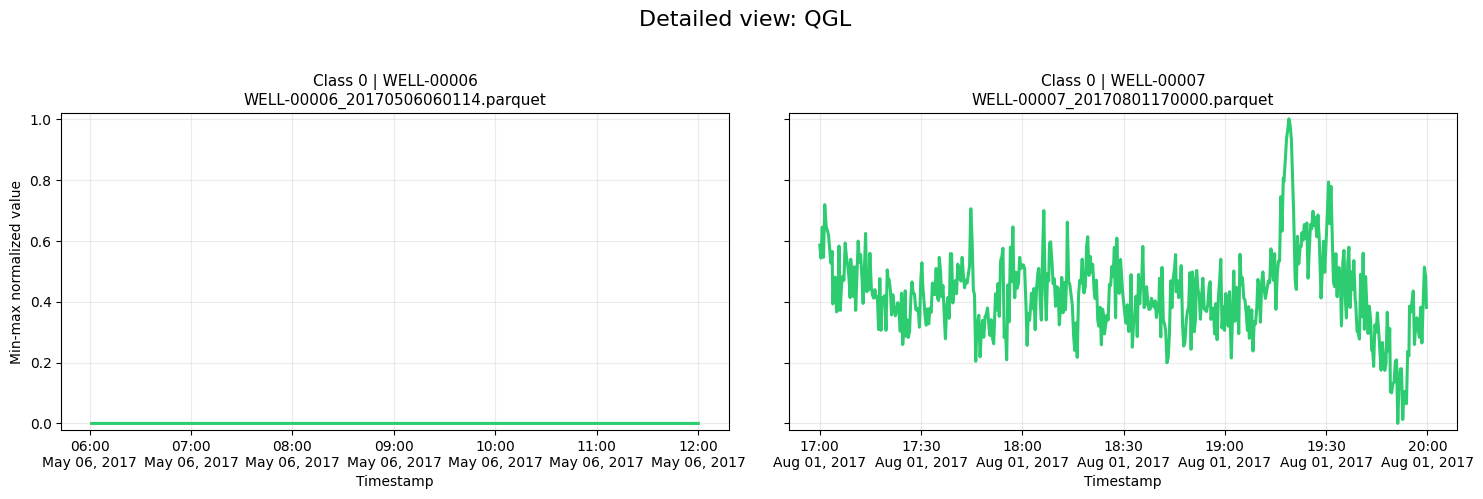

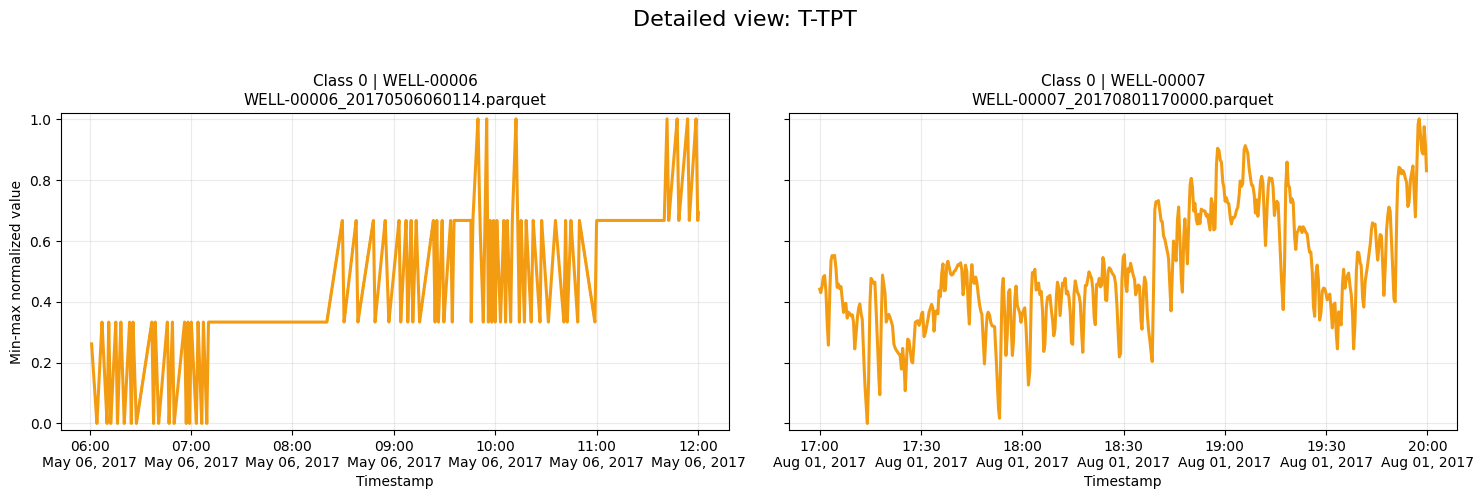

In [53]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

DETAILED_FEATURES = ['QGL', 'T-TPT']

for feature_name in DETAILED_FEATURES:
    fig, axes = plt.subplots(1, len(COMPARISON_SERIES), figsize=(15, 4.8), sharey=True)
    if len(COMPARISON_SERIES) == 1:
        axes = [axes]

    for ax, series_config in zip(axes, COMPARISON_SERIES):
        series_path = Path(series_config['file_path'])
        series_df = pd.read_parquet(series_path).copy()
        series_df.index = pd.to_datetime(series_df.index)
        series_df = series_df.sort_index()

        feature_series = pd.to_numeric(series_df[feature_name], errors='coerce')
        feature_min = feature_series.min(skipna=True)
        feature_max = feature_series.max(skipna=True)

        if pd.isna(feature_min) or pd.isna(feature_max):
            raise ValueError(f'Feature {feature_name} is empty for {series_path.name}.')
        if np.isclose(feature_max, feature_min):
            normalized_series = pd.Series(np.zeros(len(feature_series)), index=feature_series.index)
        else:
            normalized_series = (feature_series - feature_min) / (feature_max - feature_min)

        ax.plot(
            normalized_series.index,
            normalized_series,
            color=feature_colors[feature_name],
            linewidth=2.2,
        )
        ax.set_title(f"Class {series_config['class_label']} | {series_config['well_name']}\n{series_path.name}", fontsize=11)
        ax.set_ylim(-0.02, 1.02)
        ax.grid(True, alpha=0.25)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M\n%b %d, %Y'))
        if ax is axes[0]:
            ax.set_ylabel('Min-max normalized value')
        ax.set_xlabel('Timestamp')

    fig.suptitle(f'Detailed view: {feature_name}', fontsize=16, y=1.03)
    plt.tight_layout()
    plt.show()


## Time-series visual example

The cell below reproduces the style of the reference figure using the most complete real series we found in the dataset. Because no labeled series contains all `27` measurable features fully populated, the plot uses the best available candidate and keeps only the features that are fully observed in that series, excluding `class` and `state`.


Loaded parquet: /home/tiagoriosrocha/Desktop/lstm-w3/3W/dataset/8/WELL-00030_20141108012623.parquet


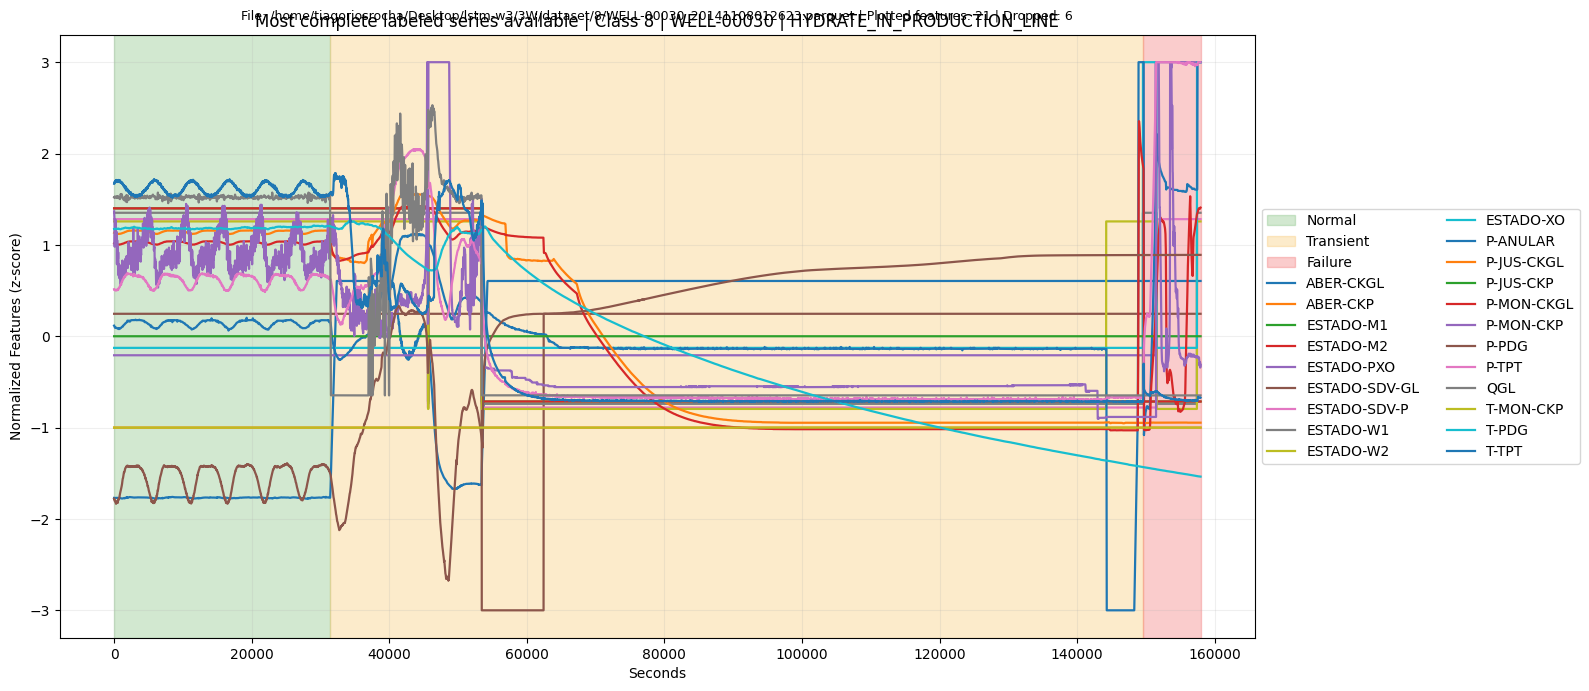

Plotted features: ['ABER-CKGL', 'ABER-CKP', 'ESTADO-M1', 'ESTADO-M2', 'ESTADO-PXO', 'ESTADO-SDV-GL', 'ESTADO-SDV-P', 'ESTADO-W1', 'ESTADO-W2', 'ESTADO-XO', 'P-ANULAR', 'P-JUS-CKGL', 'P-JUS-CKP', 'P-MON-CKGL', 'P-MON-CKP', 'P-PDG', 'P-TPT', 'QGL', 'T-MON-CKP', 'T-PDG', 'T-TPT']
Dropped incomplete features: ['ESTADO-DHSV', 'P-JUS-BS', 'P-MON-SDV-P', 'PT-P', 'QBS', 'T-JUS-CKP']


,seconds,class,ABER-CKGL,ABER-CKP,ESTADO-M1,ESTADO-M2,ESTADO-PXO,ESTADO-SDV-GL,ESTADO-SDV-P,ESTADO-W1,...,P-JUS-CKGL,P-JUS-CKP,P-MON-CKGL,P-MON-CKP,P-PDG,P-TPT,QGL,T-MON-CKP,T-PDG,T-TPT
timestamp,,,,,,,,,,,,,,,,,,,,,
2014-11-08 02:26:23,0.0,0,36.01167,-99.99,1.0,1.0,0.0,1.0,1.0,1.0,...,15743450.0,-9999000.0,15815570.0,2228333.0,21881770.0,16795630.0,1.877131,-99.99,53.66814,44.78333
2014-11-08 02:26:24,1.0,0,36.01200,-99.99,1.0,1.0,0.0,1.0,1.0,1.0,...,15743100.0,-9999000.0,15815200.0,2226667.0,21881860.0,16795630.0,1.877224,-99.99,53.66809,44.79000
2014-11-08 02:26:25,2.0,0,36.01233,-99.99,1.0,1.0,0.0,1.0,1.0,1.0,...,15742750.0,-9999000.0,15814830.0,2225000.0,21881940.0,16795630.0,1.877316,-99.99,53.66804,44.80400
2014-11-08 02:26:26,3.0,0,36.01266,-99.99,1.0,1.0,0.0,1.0,1.0,1.0,...,15742400.0,-9999000.0,15814470.0,2223333.0,21881800.0,16794250.0,1.877409,-99.99,53.66803,44.81800
2014-11-08 02:26:27,4.0,0,36.01300,-99.99,1.0,1.0,0.0,1.0,1.0,1.0,...,15742050.0,-9999000.0,15814100.0,2221667.0,21881660.0,16792870.0,1.877502,-99.99,53.66803,44.83200


In [54]:
import matplotlib.pyplot as plt
import numpy as np

TARGET_CLASS = 8
TARGET_WELL = 'WELL-00030'
EXCLUDED_COLUMNS = {'class', 'state'}
TRANSIENT_CLASS_OFFSET = 100

sample_row = manifest.loc[
    (manifest['class_label_int'] == TARGET_CLASS)
    & (manifest['well_name'] == TARGET_WELL)
].head(1)
if sample_row.empty:
    sample_row = manifest.loc[manifest['class_label_int'] == TARGET_CLASS].head(1)
if sample_row.empty:
    raise ValueError(f'No series found for class {TARGET_CLASS}.')

sample_row = sample_row.iloc[0]
sample_file_path = Path(sample_row['file_path'])
sample_df = pd.read_parquet(sample_file_path).copy()
sample_df.index = pd.to_datetime(sample_df.index)
sample_df = sample_df.sort_index()
sample_df = sample_df.loc[sample_df['class'].notna()].copy()
if sample_df.empty:
    raise ValueError('The selected series has no labeled observations.')
candidate_feature_columns = [column for column in sample_df.columns if column not in EXCLUDED_COLUMNS]
complete_feature_mask = sample_df[candidate_feature_columns].notna().all(axis=0)
FEATURE_COLUMNS = complete_feature_mask.loc[complete_feature_mask].index.tolist()
DROPPED_FEATURE_COLUMNS = complete_feature_mask.loc[~complete_feature_mask].index.tolist()
if not FEATURE_COLUMNS:
    raise ValueError('The selected series has no fully observed features to plot.')
sample_df['seconds'] = (sample_df.index - sample_df.index.min()).total_seconds()

class_series = sample_df['class'].astype('Float64')
transient_label = TARGET_CLASS + TRANSIENT_CLASS_OFFSET
phase_masks = {
    'Normal': class_series.eq(0),
    'Transient': class_series.eq(transient_label),
    'Failure': class_series.eq(TARGET_CLASS),
}
phase_colors = {
    'Normal': '#7FBF7B',
    'Transient': '#F9C66B',
    'Failure': '#F26D6D',
}

if not any(mask.fillna(False).any() for mask in phase_masks.values()):
    raise ValueError(
        'The selected series does not contain the expected phases in `class` (0, 100 + class, class).'
    )

feature_frame = sample_df[FEATURE_COLUMNS].astype(float)
normalized = (feature_frame - feature_frame.mean()) / feature_frame.std(ddof=0).replace(0, 1.0)
normalized = normalized.clip(-3.0, 3.0)

print('Loaded parquet:', sample_file_path)


fig, ax = plt.subplots(figsize=(16, 7))
for phase_name, mask in phase_masks.items():
    active = mask.fillna(False).to_numpy()
    if not active.any():
        continue
    phase_seconds = sample_df.loc[active, 'seconds']
    ax.axvspan(
        phase_seconds.min(),
        phase_seconds.max(),
        color=phase_colors[phase_name],
        alpha=0.35,
        label=phase_name,
    )

for feature_name in FEATURE_COLUMNS:
    ax.plot(sample_df['seconds'], normalized[feature_name], linewidth=1.6, label=feature_name)

event_name = event_catalog.loc[
    event_catalog['class_label'].astype(str) == str(TARGET_CLASS),
    'event_name',
].squeeze()
ax.set_title(
    f'Most complete labeled series available | Class {TARGET_CLASS} | '
    f'{sample_row["well_name"]} | {event_name}'
)
ax.text(
    0.5,
    1.02,
    f'File: {sample_file_path} | Plotted features: {len(FEATURE_COLUMNS)} | Dropped: {len(DROPPED_FEATURE_COLUMNS)}',
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=9,
    wrap=True,
)
ax.set_xlabel('Seconds')
ax.set_ylabel('Normalized Features (z-score)')
ax.grid(True, alpha=0.2)

handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=2)
plt.tight_layout()
plt.show()

print('Plotted features:', FEATURE_COLUMNS)
print('Dropped incomplete features:', DROPPED_FEATURE_COLUMNS)
sample_df[['seconds', 'class'] + FEATURE_COLUMNS].head()
